# Budget Variance Analysis Automation

This notebook connects to the BigQuery analytical layer and automates
validation, management reporting, visualization, and output generation.

## 1. Setup & BigQuery Connection
Connect to Google BigQuery and initialize the required Python libraries.

In [1]:
from google.colab import auth
auth.authenticate_user()

In [2]:
from google.cloud import bigquery
import pandas as pd

project_id = "budget-variance-portfolio"

client = bigquery.Client(project=project_id)

## 2. Data Extraction
Load executive KPIs, driver analysis and Pareto results from the
BigQuery analytical views into pandas DataFrames.

In [3]:
query = """
SELECT *
FROM `budget-variance-portfolio.budget_controlling.vw_driver_summary`
ORDER BY variance ASC
"""

driver_summary = client.query(query).to_dataframe()

driver_summary

,department,category,variance,worst_region,worst_month,transactions,issue_pct,avg_variance_per_transaction
0,Marketing,Training,-5501558.000000000,East,2021-04,280,0.664286,-19648.421428571
1,Marketing,Travel,-4134647.000000000,East,2022-08,274,0.594891,-15089.952554745
2,Operations,Salaries,-4116403.000000000,South,2021-03,258,0.581395,-15955.050387597
3,Sales,Utilities,-4067500.000000000,North,2022-09,289,0.581315,-14074.394463668
4,Operations,Utilities,-3988056.000000000,North,2023-05,305,0.586885,-13075.593442623


In [4]:
kpi_query = """
SELECT *
FROM `budget-variance-portfolio.budget_controlling.vw_executive_kpis`
"""

kpis = client.query(kpi_query).to_dataframe()

kpis

,total_budget,total_actual,total_variance,variance_pct,budget_utilization,transactions,issue_transactions,issue_pct
0,796111159.000000000,891202705.000000000,-95091546.000000000,-0.119445061,1.119445061,10010,5598,0.559241


In [5]:
pareto_query = """
SELECT *
FROM `budget-variance-portfolio.budget_controlling.vw_pareto_analysis`
ORDER BY driver_rank
"""

pareto = client.query(pareto_query).to_dataframe()

pareto.head(10)

,driver_rank,department,category,variance,abs_variance,share_pct,cumulative_pct
0,1,Marketing,Training,-5501558.000000000,5501558.000000000,0.057804206,0.057804206
1,2,Marketing,Travel,-4134647.000000000,4134647.000000000,0.043442237,0.101246443
2,3,Operations,Salaries,-4116403.000000000,4116403.000000000,0.043250549,0.144496992
3,4,Sales,Utilities,-4067500.000000000,4067500.000000000,0.042736731,0.187233723
4,5,Operations,Utilities,-3988056.000000000,3988056.000000000,0.041902023,0.229135746
5,6,IT,Salaries,-3974415.000000000,3974415.000000000,0.041758699,0.270894445
6,7,HR,Training,-3699628.000000000,3699628.000000000,0.038871545,0.309765990
7,8,Marketing,Marketing,-3638120.000000000,3638120.000000000,0.038225288,0.347991278
8,9,Operations,Marketing,-3621586.000000000,3621586.000000000,0.038051567,0.386042845
9,10,Marketing,Salaries,-3510773.000000000,3510773.000000000,0.036887268,0.422930113


## 3. Data Validation
Validate key financial metrics against the previously reconciled
Google Sheets and SQL results.

In [6]:
expected = {
    "total_budget": 796_111_159,
    "total_actual": 891_202_705,
    "total_variance": -95_091_546
}

actual = kpis.iloc[0]

for metric, expected_value in expected.items():
    actual_value = actual[metric]
    status = "PASS" if round(actual_value, 2) == round(expected_value, 2) else "FAIL"
    print(f"{metric}: {actual_value:,.2f} | expected: {expected_value:,.2f} | {status}")

total_budget: 796,111,159.00 | expected: 796,111,159.00 | PASS
total_actual: 891,202,705.00 | expected: 891,202,705.00 | PASS
total_variance: -95,091,546.00 | expected: -95,091,546.00 | PASS


## 4. Driver Analysis
Identify the largest unfavorable variance driver and its main
regional and temporal characteristics.

In [7]:
top_driver = driver_summary.iloc[0]

print("Top driver:")
print(f"{top_driver['department']} × {top_driver['category']}")
print(f"Variance: {top_driver['variance']:,.0f}")
print(f"Worst region: {top_driver['worst_region']}")
print(f"Worst month: {top_driver['worst_month']}")

Top driver:
Marketing × Training
Variance: -5,501,558
Worst region: East
Worst month: 2021-04


## 5. Automated Visualizations
Generate management-level visualizations of the largest unfavorable
variance drivers and their cumulative contribution.

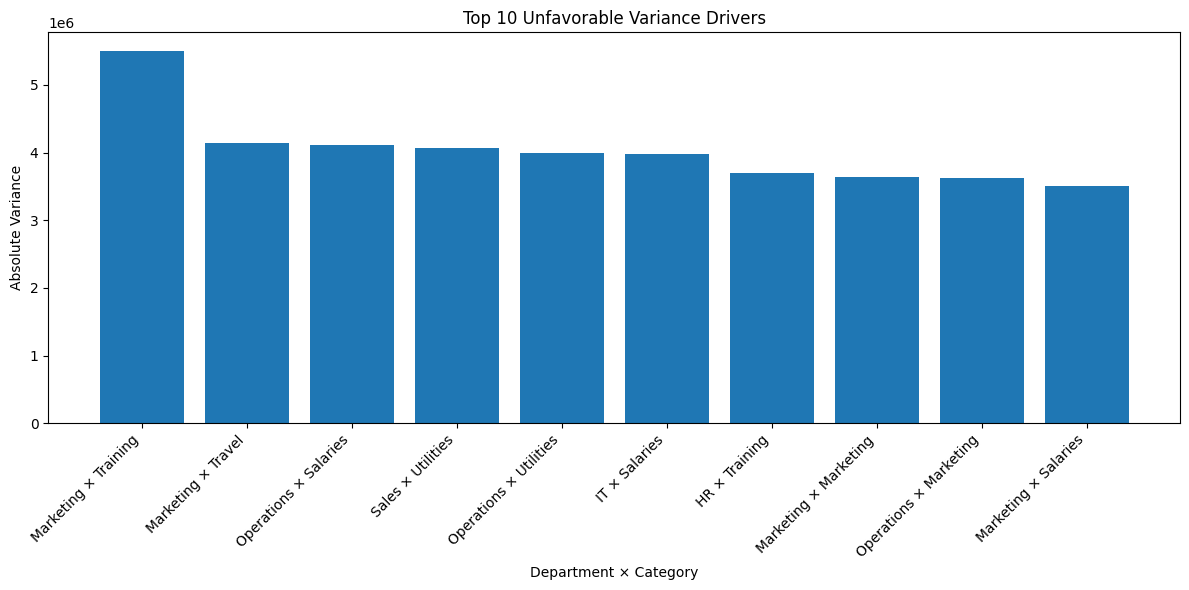

In [8]:
import matplotlib.pyplot as plt

top10 = pareto.head(10).copy()

labels = top10["department"] + " × " + top10["category"]

plt.figure(figsize=(12, 6))
plt.bar(labels, top10["abs_variance"])

plt.title("Top 10 Unfavorable Variance Drivers")
plt.xlabel("Department × Category")
plt.ylabel("Absolute Variance")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

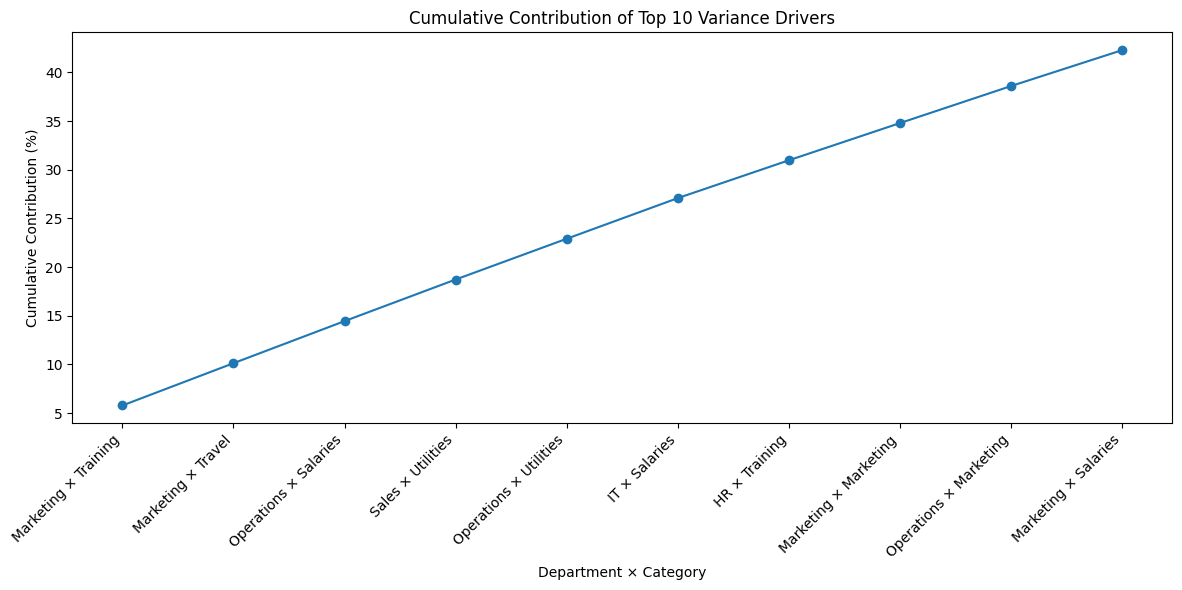

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    labels,
    top10["cumulative_pct"] * 100,
    marker="o"
)

plt.title("Cumulative Contribution of Top 10 Variance Drivers")
plt.xlabel("Department × Category")
plt.ylabel("Cumulative Contribution (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 6. Management Summary
Automatically generate a management narrative based on the latest
analytical results.

In [10]:
overall = kpis.iloc[0]
top_driver = driver_summary.iloc[0]
top10_concentration = pareto.head(10)["share_pct"].sum()

management_summary = f"""
Budget Performance Summary

Actual spending exceeded budget by {abs(overall['variance_pct']) * 100:.2f}%,
resulting in an unfavorable variance of {abs(overall['total_variance']) / 1_000_000:.1f}M.

The largest unfavorable driver was
{top_driver['department']} × {top_driver['category']},
with a variance of {top_driver['variance'] / 1_000_000:.2f}M.

The Top 10 unfavorable drivers accounted for
{top10_concentration * 100:.2f}% of total unfavorable variance,
indicating that the overspend was distributed across multiple cost drivers.

For the largest driver, the worst-performing region was
{top_driver['worst_region']}, while the worst month was
{top_driver['worst_month']}.
"""

print(management_summary)


Budget Performance Summary

Actual spending exceeded budget by 11.94%,
resulting in an unfavorable variance of 95.1M.

The largest unfavorable driver was
Marketing × Training,
with a variance of -5.50M.

The Top 10 unfavorable drivers accounted for
42.29% of total unfavorable variance,
indicating that the overspend was distributed across multiple cost drivers.

For the largest driver, the worst-performing region was
East, while the worst month was
2021-04.



## 7. Export
Export the main analytical outputs for downstream reporting or further analysis.

In [11]:
kpis.to_csv("executive_kpis.csv", index=False)
driver_summary.to_csv("driver_summary.csv", index=False)
pareto.to_csv("pareto_analysis.csv", index=False)

with open("management_summary.txt", "w") as file:
    file.write(management_summary)

print("Files exported successfully.")

Files exported successfully.
